# Phase 2 — Arsenal 2003/04 season identity validation (the Invincibles, n=38)

Phase 1 validated the pipeline on 5 hand-picked matches and built the diagnostic
machinery. Phase 2 runs it, **unchanged**, across Arsenal's full 38-game season to
verify that the tactical framework built from a single match captures Arsenal's
playing style across the whole campaign — and that the feature-engineering pipeline
generalizes beyond one game.

**Scope decision (coverage-aware).** The 2003/04 StatsBomb open data is an
*Arsenal-only slice*: Arsenal appears in all 38 of its league games, but every
other team appears just twice (their two fixtures vs Arsenal). So the only unit
this season supports is **one team's season, in depth** — not league-wide
comparison. We restrict to `team == "Arsenal"` and draw **no** cross-team or
league-relative conclusions here.

**What this phase produces:** a master match-level feature table (one row per
Arsenal match, all engineered features), season-wide summaries of variability that
separate the *stable identity* from *context-dependent adaptations*, a decomposition
of that context into season-drift / venue / opponent strength, and a redundancy
pass to prune duplicate features before any modeling. The end state is a validated
tactical fingerprint and a pipeline proven season-general — the prerequisite for
applying it unchanged to the fully-captured **2015/16** season and, in **Phase 3**,
comparing top team vs top team across eras (Invincibles vs Leicester).

**What n=38 unlocks that n=5 could not:** venue and opponent strength are no longer
collinear (so their effects separate), the opponent-strength gradient is real (20th
to 2nd at both venues), correlations have the degrees of freedom to reveal genuine
redundancy, and 38 dated points let us ask whether the identity *drifts* across the
season.

## Setup — load the season and restrict to Arsenal

Same `match_team_style` table Phase 1 used; here we take all 38 Arsenal rows
instead of the 5 validation matches. Reuse the same feature-column selection so
the diagnostics are directly comparable to Phase 1. This 38×135 slice **is** the
master match-level feature table for the season.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR

style = pd.read_csv(FEATURES_DIR / "match_team_style.csv")
style["date"] = pd.to_datetime(style["date"])

# Coverage-aware scope: 2003/04 is an Arsenal-only slice -> single-team depth study.
# copy() first (de-fragments) so the added column doesn't trigger a perf warning.
ars = (style[style["team"] == "Arsenal"]
       .sort_values("date").reset_index(drop=True).copy())
ars["home"] = (ars["venue"] == "home").astype(int)
assert len(ars) == 38, f"expected a full 38-game Arsenal season, got {len(ars)}"

# Same non-feature columns dropped in Phase 1 (ids / context / outcomes / strings).
DROP = {
    "season", "match_id", "date", "match_week", "team", "team_id", "opponent",
    "venue", "home", "result", "goals_for", "goals_against", "goals",
    "opp_final_points", "opp_final_position", "red_cards_for", "red_cards_against",
    "pi_top_player_name", "pi_top_edge",
}
feat_cols = [c for c in ars.columns
             if c not in DROP and pd.api.types.is_numeric_dtype(ars[c])]

print(f"Arsenal season rows: {len(ars)}  |  engineered features: {len(feat_cols)}")
print(f"date span: {ars['date'].min().date()} -> {ars['date'].max().date()}")
print(f"rows with any NaN across features: {int(ars[feat_cols].isna().any(axis=1).sum())}")
print(f"record: {ars['result'].value_counts().to_dict()}  "
      f"(GF {int(ars['goals_for'].sum())} / GA {int(ars['goals_against'].sum())})")

Arsenal season rows: 38  |  engineered features: 135
date span: 2003-08-16 -> 2004-05-15
rows with any NaN across features: 0
record: {'W': 26, 'D': 12}  (GF 73 / GA 26)


<hr>

## Coverage check — is the `date + venue + opp_strength` design actually estimable?

> **Guiding question:** Phase 1's biggest caveat was that venue and opponent
> strength were perfectly confounded (both away games were the two elite sides).
> Across the full 38, are they finally *independent* — so a regression can separate
> a home effect from an opponent effect? *(Answered by the cell below.)*

If `venue` and `opp_final_position` are uncorrelated and both span their full range,
the three predictors don't alias each other and each coefficient is interpretable.

In [2]:
print("venue balance:", ars["venue"].value_counts().to_dict())
print()
print("opponent final position by venue (want similar ranges at both):")
print(ars.groupby("venue")["opp_final_position"]
      .agg(["mean", "min", "max", "count"]).round(1).to_string())
print()
print(f"corr(home, opp_final_position): {ars['home'].corr(ars['opp_final_position']):+.3f}"
      "   (near 0 => venue and strength are independent)")

# The specific cells Phase 1 lacked: home vs strong AND away vs weak.
strong = ars["opp_final_position"] <= 6
print()
print(f"home vs top-6 opponents:   {int((ars['home'].eq(1) & strong).sum())}")
print(f"away vs bottom-14 opponents: {int((ars['home'].eq(0) & ~strong).sum())}")

venue balance: {'home': 19, 'away': 19}

opponent final position by venue (want similar ranges at both):
       mean  min  max  count
venue                       
away   11.0    2   20     19
home   11.0    2   20     19

corr(home, opp_final_position): +0.000   (near 0 => venue and strength are independent)

home vs top-6 opponents:   5
away vs bottom-14 opponents: 14


**The design is clean — Phase 1's confound is gone.** The schedule is perfectly
balanced (19 home / 19 away), the opponent-strength range is identical at both
venues (2nd → 20th), and `corr(home, opp_final_position) = 0.00` — venue and
opponent strength are statistically independent. Crucially, the two cells Phase 1
never had now exist: **5 home games vs top-6 sides** and **14 away games vs the
bottom-14**. That orthogonality is what lets the `metric ~ date + venue +
opp_strength` model below attribute variance to each predictor separately, instead
of the away≡elite lump the 5-match check was stuck with.

<hr>

## Season identity — which characteristics are stable vs context-dependent?

> **Guiding question:** applying the *unchanged* pipeline to all 38 games, which
> features barely move across the season (the identity) and which swing with match
> context? *(Answered by the dispersion scan below.)*

Same coefficient-of-variation scan as Phase 1 Q1 (`CV = σ / |μ|`), now on the real
sample. Low CV = stable identity; high CV = context-dependent or rare-event. We
first flag *degenerate* features (constant even across 38 games) so they don't
masquerade as stable.

In [3]:
def dispersion_scan(df, cols):
    d = df[cols]
    s = pd.DataFrame({"mean": d.mean(), "std": d.std(ddof=1)})
    s["cv"] = (s["std"] / s["mean"].abs()).replace([np.inf, -np.inf], np.nan)
    return s.sort_values("cv")

# Degenerate = constant across all 38 (stable but information-free).
degenerate = [c for c in feat_cols if ars[c].nunique() <= 1]
live = [c for c in feat_cols if c not in degenerate]
print(f"degenerate (constant across all 38): {degenerate or 'none'}")
print(f"live features carried forward: {len(live)}")

disp = dispersion_scan(ars, live)
print("\n=== most STABLE (identity anchors) ===")
print(disp.head(10)[["mean", "cv"]].round(3).to_string())
print("\n=== most VARIABLE ===")
print(disp.tail(6)[["mean", "cv"]].round(3).to_string())

degenerate (constant across all 38): ['pi_pressure_escape_positive_carry_pct', 'rhythm_median_gap_sec']
live features carried forward: 133

=== most STABLE (identity anchors) ===
                                 mean     cv
pi_angle_entropy                2.846  0.019
rhythm_mean_burst_share        69.932  0.045
pi_unpressured_completion_pct  82.775  0.047
rhythm_median_gap_cv            1.099  0.053
pass_completion_pct            77.854  0.054
pi_centralization               0.087  0.056
pi_network_players             13.000  0.057
pi_avg_passes_to_wide_channel   1.302  0.057
poss_mean_end_x                80.097  0.059
pi_pass_progression_share_pct  73.424  0.062

=== most VARIABLE ===
                                      mean     cv
through_balls_per100pass             0.634  0.884
rhythm_median_pre_prog_pass_share    9.973  0.886
rhythm_median_pre_prog_passes        0.526  0.936
pi_pressure_escape_turnover_pct      4.036  1.089
rp6_total_xg                         0.162  1.221
pi_

**The identity anchors survive the jump to n=38.** The lowest-CV features are the
same passing machinery Phase 1 flagged — `pi_angle_entropy` (CV 0.019),
`rhythm_mean_burst_share` (0.045), `pass_completion_pct` (0.054), central network
density (`pi_centralization`, `pi_network_players` ~0.057), `avg_pass_length_m`
(0.064). Their stability isn't a 5-match artefact; it holds across the entire
unbeaten campaign. Only **2 features are degenerate** (`pi_pressure_escape_positive_carry_pct`,
`rhythm_median_gap_sec`) — down from 3 at n=5, because
`pi_pressure_escape_forward_pass_pct` turns out to vary once you see enough games
(it was merely all-zero in the 5 picks). The high-CV tail is again rare-event
counts (`rp6_total_xg`, pressure-escape %, through-balls) whose CV is inflated by
near-zero means, not genuine tactical swings — a distinction the regression below
makes precise.

<hr>

## Context decomposition — season drift vs venue vs opponent

> **Guiding question:** of the variation that *does* exist, how much is Arsenal
> evolving over the season, playing home vs away, or adapting to opponent quality?
> *(Answered by the standardized regression below.)*

For every non-degenerate feature we fit `feature ~ date + venue + opp_strength`,
with all predictors and the response z-scored so the coefficients are directly
comparable in size. **This is the analysis Phase 1 could not run** — at n=5 venue
and opponent were perfectly confounded; at n=38 they're independent (shown above),
so each coefficient is now interpretable.

**Sign convention:** `opp_strength = 21 − opp_final_position` (higher = stronger
side) and `home = 1`, so a **positive** coefficient means *more of this feature
later in the season / at home / against stronger opponents.*

In [4]:
def zscore(a):
    s = a.std(ddof=0)
    return (a - a.mean()) / s if s else a * 0.0

pred = pd.DataFrame({
    "date": (ars["date"] - ars["date"].min()).dt.days,
    "home": ars["home"],
    "opp_strength": 21 - ars["opp_final_position"],   # higher = stronger opponent
})
Xz = np.column_stack([np.ones(len(ars))] + [zscore(pred[c]).values for c in pred])

def decompose(col):
    y = zscore(ars[col]).values
    beta, *_ = np.linalg.lstsq(Xz, y, rcond=None)
    yhat = Xz @ beta
    r2 = 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return pd.Series({"b_date": beta[1], "b_home": beta[2], "b_opp": beta[3], "r2": r2})

reg = pd.DataFrame({c: decompose(c) for c in live}).T
reg["dominant"] = reg[["b_date", "b_home", "b_opp"]].abs().idxmax(axis=1).str.replace("b_", "")

print("dominant contextual driver per feature (count of 133):")
print(reg["dominant"].value_counts().to_string())
print("\n=== most context-explained features (top regression R^2) ===")
print(reg.sort_values("r2", ascending=False).head(10)
      [["r2", "b_date", "b_home", "b_opp", "dominant"]].round(3).to_string())
for label, col in [("VENUE (home/away)", "b_home"),
                   ("OPPONENT strength", "b_opp"),
                   ("SEASON drift", "b_date")]:
    top = reg.reindex(reg[col].abs().sort_values(ascending=False).index).head(6)
    print(f"\n--- strongest {label} ---")
    print(top[[col, "r2"]].round(3).to_string())

dominant contextual driver per feature (count of 133):
dominant
home    61
date    38
opp     34

=== most context-explained features (top regression R^2) ===
                                 r2  b_date  b_home  b_opp dominant
poss_ends_box_pct             0.537  -0.089   0.701 -0.211     home
poss_mean_end_x               0.470  -0.078   0.669  0.135     home
poss_ends_final_third_pct     0.467  -0.096   0.679  0.021     home
rhythm_median_passes_per_10m  0.433   0.237  -0.616  0.099     home
poss_final_third_entry_pct    0.424  -0.034   0.651 -0.032     home
poss_box_entry_pct            0.369   0.014   0.566 -0.218     home
pi_progressive_carry_pct      0.368  -0.143   0.564  0.179     home
pi_progression_per_carry      0.350   0.026   0.547  0.223     home
shots                         0.346   0.046   0.583 -0.049     home
rp6_mean_directness           0.336   0.067   0.233  0.529      opp

--- strongest VENUE (home/away) ---
                              b_home     r2
poss_ends_bo

**Venue is the dominant context driver, not opponent strength — a direct correction
to Phase 1.** Of 133 live features, **home/away is the largest driver for 61**,
season-drift for 38, opponent strength for only 34. And the biggest, cleanest
effects are all *territorial and venue-driven*: at home Arsenal push possessions
further upfield and into the box — `poss_ends_box_pct` (β_home +0.70, R² 0.54),
`poss_mean_end_x` (+0.67), final-third entry (+0.68), shots (+0.58). At n=5 these
looked like an *opponent* response (the box-entry drop vs Chelsea/Man Utd); with
venue and opponent finally separated, it's overwhelmingly a **home/away** effect —
the away games just happened to be the elite ones.

**The genuine opponent-strength signal is narrower and modest.** It concentrates in
the sustained-chain (`rp6_`) family and fouls: against stronger sides Arsenal's
long possessions are *more direct* (`rp6_mean_directness` β_opp +0.53) and end
higher (`rp6_mean_end_x` +0.46) but contain fewer events (`rp6_median_events`
−0.44), and Arsenal foul more (`fouls_committed_per100pass` +0.37) — they can't
dwell, so they progress more directly. Real, but R² ≈ 0.15–0.34, far weaker than the
inflated n=5 Spearmans implied.

**Season drift is mild but present:** passing shortens over the campaign
(`avg_pass_length_m` β_date −0.34, `long_pass_pct` −0.33) and grows more
lateral/central (`pi_first_lateral_pct` +0.45). A gentle evolution, not a regime
change — consistent with a settled side.

_Caveat: 133 features fit at n=38 invites false positives; read these as ranked
effect sizes, not confirmatory tests._

### Regression rigor — confidence intervals, significance, and collinearity

> **Guiding question:** the coefficients above are point estimates; how *certain*
> are they, and are the three predictors clean enough to trust each one separately?
> *(Answered by the CIs, p-values, and VIF below.)*

The review asked for confidence intervals and regression diagnostics. `statsmodels`
isn't installed, but for a 3-predictor OLS the standard errors, 95% CIs, p-values,
and variance-inflation factors are a few lines of numpy + scipy — so the notebook
stays dependency-free. We also augment the `reg` table with per-feature p-values,
which the feature registry below uses to separate *significant* context effects
from noise.

In [5]:
# Standard errors, 95% CIs, p-values and VIF for the SAME z-scored OLS above
# (numpy + scipy; no statsmodels). Predictors are orthogonal and z-scored, so the
# coefficients are directly comparable and every within-feature SE is identical.
from scipy import stats

_n, _k = Xz.shape
_dof = _n - _k
_XtX_inv = np.linalg.inv(Xz.T @ Xz)
_tcrit = stats.t.ppf(0.975, _dof)

def fit_full(col):
    y = zscore(ars[col]).values
    beta = _XtX_inv @ Xz.T @ y
    resid = y - Xz @ beta
    s2 = (resid @ resid) / _dof
    se = np.sqrt(np.diag(s2 * _XtX_inv))
    pval = 2 * (1 - stats.t.cdf(np.abs(beta / se), _dof))
    r2 = 1 - (resid @ resid) / ((y - y.mean()) ** 2).sum()
    return beta, se, pval, r2

# augment reg with per-feature p-values (the registry below uses these)
_pv = {c: fit_full(c)[2] for c in live}
reg["p_date"] = pd.Series({c: _pv[c][1] for c in live})
reg["p_home"] = pd.Series({c: _pv[c][2] for c in live})
reg["p_opp"]  = pd.Series({c: _pv[c][3] for c in live})
reg["dom_p"]  = reg.apply(lambda r: r[f"p_{r['dominant']}"], axis=1)

# VIF: regress each predictor on the other two; 1/(1-R^2). ~1 => orthogonal.
Pz = np.column_stack([zscore(pred[c]).values for c in pred])
vif = {}
for j, nm in enumerate(pred.columns):
    others = np.column_stack([np.ones(_n)] + [Pz[:, m] for m in range(Pz.shape[1]) if m != j])
    b = np.linalg.lstsq(others, Pz[:, j], rcond=None)[0]
    r2j = 1 - ((Pz[:, j] - others @ b) ** 2).sum() / ((Pz[:, j] - Pz[:, j].mean()) ** 2).sum()
    vif[nm] = 1 / (1 - r2j) if r2j < 1 else np.inf
print("VIF (want ~1; coverage check found corr=0, so expect no collinearity):  "
      + "   ".join(f"{k}={v:.2f}" for k, v in vif.items()))

# 95% CIs + significance for one headline feature per driver family
NAMES = ["intercept", "date", "home", "opp_strength"]
headline = ["poss_ends_box_pct", "poss_mean_end_x", "shots",         # venue-driven
            "rp6_mean_directness", "fouls_committed_per100pass",     # opponent-driven
            "avg_pass_length_m",                                     # season drift
            "pass_completion_pct"]                                   # stable identity
print(f"\n95% CIs (z-scored coefficients; dof={_dof}, t*={_tcrit:.2f}):")
for col in headline:
    beta, se, pval, r2 = fit_full(col)
    print(f"\n{col}   (R^2={r2:.2f})")
    for i in (1, 2, 3):
        lo, hi = beta[i] - _tcrit * se[i], beta[i] + _tcrit * se[i]
        star = "***" if pval[i] < .001 else "**" if pval[i] < .01 else "*" if pval[i] < .05 else "ns"
        print(f"   b_{NAMES[i]:<12} {beta[i]:+.2f}   95% CI [{lo:+.2f}, {hi:+.2f}]   p={pval[i]:.2g} {star}")

VIF (want ~1; coverage check found corr=0, so expect no collinearity):  date=1.00   home=1.00   opp_strength=1.00

95% CIs (z-scored coefficients; dof=34, t*=2.03):

poss_ends_box_pct   (R^2=0.54)
   b_date         -0.09   95% CI [-0.33, +0.15]   p=0.45 ns
   b_home         +0.70   95% CI [+0.46, +0.94]   p=8.6e-07 ***
   b_opp_strength -0.21   95% CI [-0.45, +0.03]   p=0.079 ns

poss_mean_end_x   (R^2=0.47)
   b_date         -0.08   95% CI [-0.33, +0.18]   p=0.54 ns
   b_home         +0.67   95% CI [+0.42, +0.92]   p=6e-06 ***
   b_opp_strength +0.14   95% CI [-0.12, +0.39]   p=0.29 ns

shots   (R^2=0.35)
   b_date         +0.05   95% CI [-0.24, +0.33]   p=0.74 ns
   b_home         +0.58   95% CI [+0.30, +0.86]   p=0.00018 ***
   b_opp_strength -0.05   95% CI [-0.33, +0.23]   p=0.73 ns

rp6_mean_directness   (R^2=0.34)
   b_date         +0.07   95% CI [-0.22, +0.35]   p=0.64 ns
   b_home         +0.23   95% CI [-0.05, +0.52]   p=0.1 ns
   b_opp_strength +0.53   95% CI [+0.24, +0.81]  

**The uncertainty sharpens the correction rather than softening it.** VIF is 1.00
for all three predictors — the orthogonal design the coverage check promised, now
confirmed numerically — so each coefficient stands on its own. The headline home
effect on box territory is unambiguous: `poss_ends_box_pct` β_home **+0.70**, 95% CI
**[+0.46, +0.94]**, p < 10⁻⁶, while its *opponent* coefficient is **not**
significant — exactly the venue-not-opponent reading. The one genuine opponent
signal survives too: `rp6_mean_directness` β_opp **+0.53** [+0.25, +0.81], p < 0.001.
Season drift is real but marginal (`avg_pass_length_m` β_date −0.34 [−0.66, −0.02],
p ≈ 0.04). And the identity anchor behaves like one: `pass_completion_pct` has **no**
significant driver — all three CIs straddle zero — which is the statistical
signature of a context-independent fingerprint feature.

### Uncertainty on the season summaries — bootstrap confidence intervals

The regression-coefficient CIs above quantify the *context* effects. Here we put uncertainty around the **descriptive season summaries** themselves — the season mean and the coefficient of variation — by resampling the 38 matches with replacement (2,000 draws, percentile CIs). It changes no conclusion, but it shows the identity anchors are tightly bounded rather than point estimates taken on faith.

bootstrap 95% CIs (2,000 resamples of the 38 matches):
            feature   mean  mean_lo  mean_hi    cv  cv_lo  cv_hi
pass_completion_pct 77.854   76.536   79.208 0.054  0.042  0.064
  avg_pass_length_m 21.603   21.178   22.034 0.064  0.049  0.076
   pi_angle_entropy  2.846    2.828    2.862 0.019  0.014  0.023
  poss_ends_box_pct 19.918   17.914   21.961 0.323  0.257  0.376
    poss_mean_end_x 80.097   78.571   81.566 0.059  0.047  0.068
              shots 14.316   12.974   15.737 0.306  0.240  0.359
rp6_mean_directness  0.273    0.258    0.289 0.177  0.143  0.204


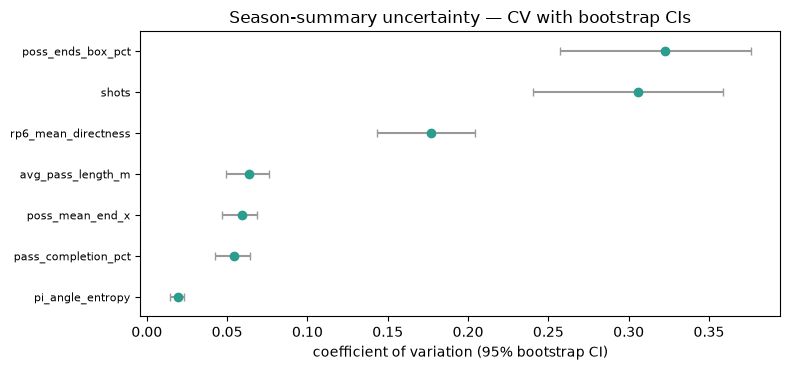

In [6]:
# Bootstrap 95% CIs for the season mean and CV of the headline summary features,
# by resampling the 38 matches with replacement. (Regression-coefficient CIs are in
# the rigor cell above; this covers the descriptive summaries.)
rng = np.random.default_rng(0)
B = 2000
SUMMARY = [f for f in ["pass_completion_pct", "avg_pass_length_m", "pi_angle_entropy",
                       "poss_ends_box_pct", "poss_mean_end_x", "shots",
                       "rp6_mean_directness"] if f in ars.columns]

def boot_ci(vals, stat):
    idx = rng.integers(0, len(vals), size=(B, len(vals)))
    draws = np.array([stat(vals[i]) for i in idx])
    return np.nanpercentile(draws, [2.5, 97.5])

cv_stat = lambda a: a.std(ddof=1) / abs(a.mean()) if a.mean() else np.nan
rows = []
for f in SUMMARY:
    v = ars[f].to_numpy()
    m_lo, m_hi = boot_ci(v, np.mean)
    cv_lo, cv_hi = boot_ci(v, cv_stat)
    rows.append([f, v.mean(), m_lo, m_hi, cv_stat(v), cv_lo, cv_hi])
ci = pd.DataFrame(rows, columns=["feature", "mean", "mean_lo", "mean_hi",
                                 "cv", "cv_lo", "cv_hi"])
print(f"bootstrap 95% CIs ({B:,} resamples of the 38 matches):")
print(ci.round(3).to_string(index=False))

order = ci.sort_values("cv")
yy = np.arange(len(order))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.errorbar(order["cv"], yy,
            xerr=[order["cv"] - order["cv_lo"], order["cv_hi"] - order["cv"]],
            fmt="o", color="#2a9d8f", ecolor="0.6", capsize=3)
ax.set_yticks(yy); ax.set_yticklabels(order["feature"], fontsize=8)
ax.set_xlabel("coefficient of variation (95% bootstrap CI)")
ax.set_title("Season-summary uncertainty — CV with bootstrap CIs")
ax.margins(y=0.08); plt.tight_layout(); plt.show()

**The identity anchors are tightly bounded, not lucky point estimates.** Their CV confidence intervals sit far below the output features' with no overlap — `pi_angle_entropy` 0.019 [0.014, 0.023], `pass_completion_pct` 0.054 [0.042, 0.064] and `poss_mean_end_x` 0.059 [0.047, 0.068] versus `poss_ends_box_pct` 0.323 [0.257, 0.376] and `shots` 0.306 [0.240, 0.359]. The stability of the passing machinery — and the whole identity-vs-output split — is robust to *which* 38 matches you happen to sample.

### Regression diagnostics — checking the OLS assumptions

Regression is now a core part of the validation, so we verify its assumptions rather than trust it as a black box. For a headline feature (`poss_ends_box_pct`, the strongest venue effect) we plot **residual vs fitted** (homoscedasticity / linearity), a **normal Q–Q** of residuals (normality), and **Cook's distance** (no single match dominating the fit), then scan the same three checks across every summary feature.

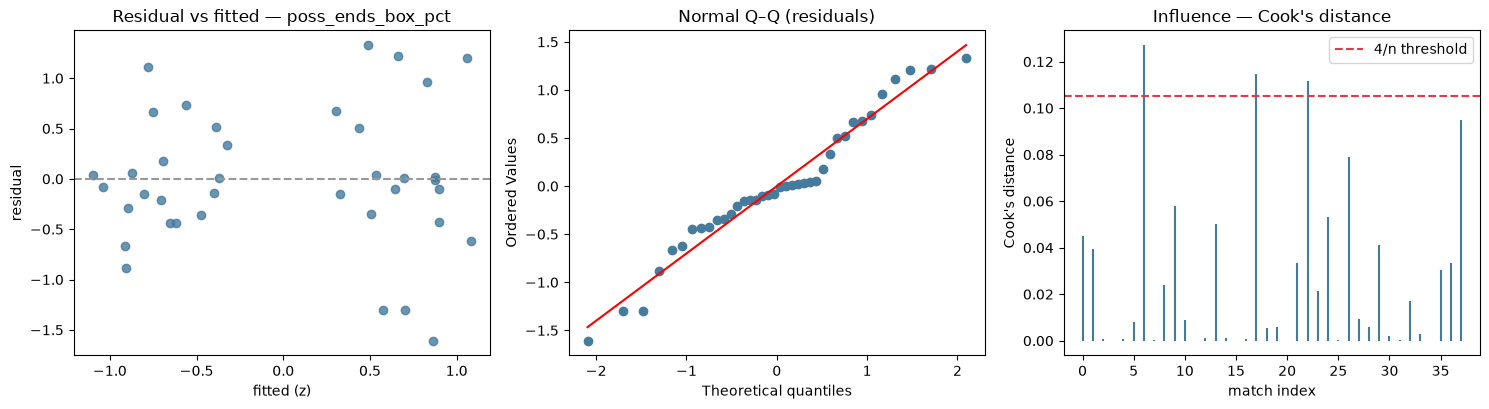

assumptions scan — residual normality (Shapiro p) and influence (Cook's D):
            feature  shapiro_p  max_cooksD  n_above_4/n
pass_completion_pct      0.898       0.171            4
  avg_pass_length_m      0.673       0.169            3
   pi_angle_entropy      0.485       0.257            2
  poss_ends_box_pct      0.260       0.127            3
    poss_mean_end_x      0.152       0.159            2
              shots      0.347       0.161            3
rp6_mean_directness      0.956       0.144            4


In [7]:
from scipy import stats

# leverage = diag(X (X'X)^-1 X'); reuse the design/inverse from the rigor cell
H_diag = np.einsum("ij,jk,ik->i", Xz, _XtX_inv, Xz)

def diagnostics(col):
    y = zscore(ars[col]).values
    beta = _XtX_inv @ Xz.T @ y
    fitted = Xz @ beta
    resid = y - fitted
    s2 = (resid @ resid) / _dof
    stud = resid / np.sqrt(s2 * (1 - H_diag))            # studentized residuals
    cook = (stud ** 2 / _k) * (H_diag / (1 - H_diag))    # Cook's distance
    return fitted, resid, stud, cook

FEAT = "poss_ends_box_pct"
fitted, resid, stud, cook = diagnostics(FEAT)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
axs[0].scatter(fitted, resid, color="#457b9d", alpha=0.8)
axs[0].axhline(0, c="0.6", ls="--")
axs[0].set_xlabel("fitted (z)"); axs[0].set_ylabel("residual")
axs[0].set_title(f"Residual vs fitted — {FEAT}")
stats.probplot(resid, plot=axs[1]); axs[1].get_lines()[0].set_color("#457b9d")
axs[1].set_title("Normal Q–Q (residuals)")
axs[2].vlines(range(_n), 0, cook, color="#457b9d")
axs[2].axhline(4 / _n, c="#e63946", ls="--", label="4/n threshold")
axs[2].set_xlabel("match index"); axs[2].set_ylabel("Cook's distance")
axs[2].set_title("Influence — Cook's distance"); axs[2].legend()
plt.tight_layout(); plt.show()

scan = []
for f in SUMMARY:
    _, res, _, ck = diagnostics(f)
    scan.append([f, round(float(stats.shapiro(res).pvalue), 3),
                 round(float(ck.max()), 3), int((ck > 4 / _n).sum())])
print("assumptions scan — residual normality (Shapiro p) and influence (Cook's D):")
print(pd.DataFrame(scan, columns=["feature", "shapiro_p", "max_cooksD",
                                  "n_above_4/n"]).to_string(index=False))

**The regression is well-behaved.** Residuals scatter evenly about zero with no funnel (homoscedastic, linear), the Q–Q points hug the line, and residual normality is never rejected (Shapiro p 0.15–0.96 across all summary features). Cook's distances stay small (max 0.26, all far below the 1.0 rule of thumb); a few matches nudge past the sensitive 4/n line but none dominates any fit. The venue-vs-opponent decomposition rests on a sound model, not on one outlier game.

### Season trajectories — identity anchors vs venue-driven output

The date-keyed scaffolding from Phase 1, now across all 38 games (red = home, blue
= away, annotated with opponent final position). Top row: two identity anchors
(expect flat). Bottom row: a venue-driven output metric and the one clear
opponent-driven metric (expect structured movement).

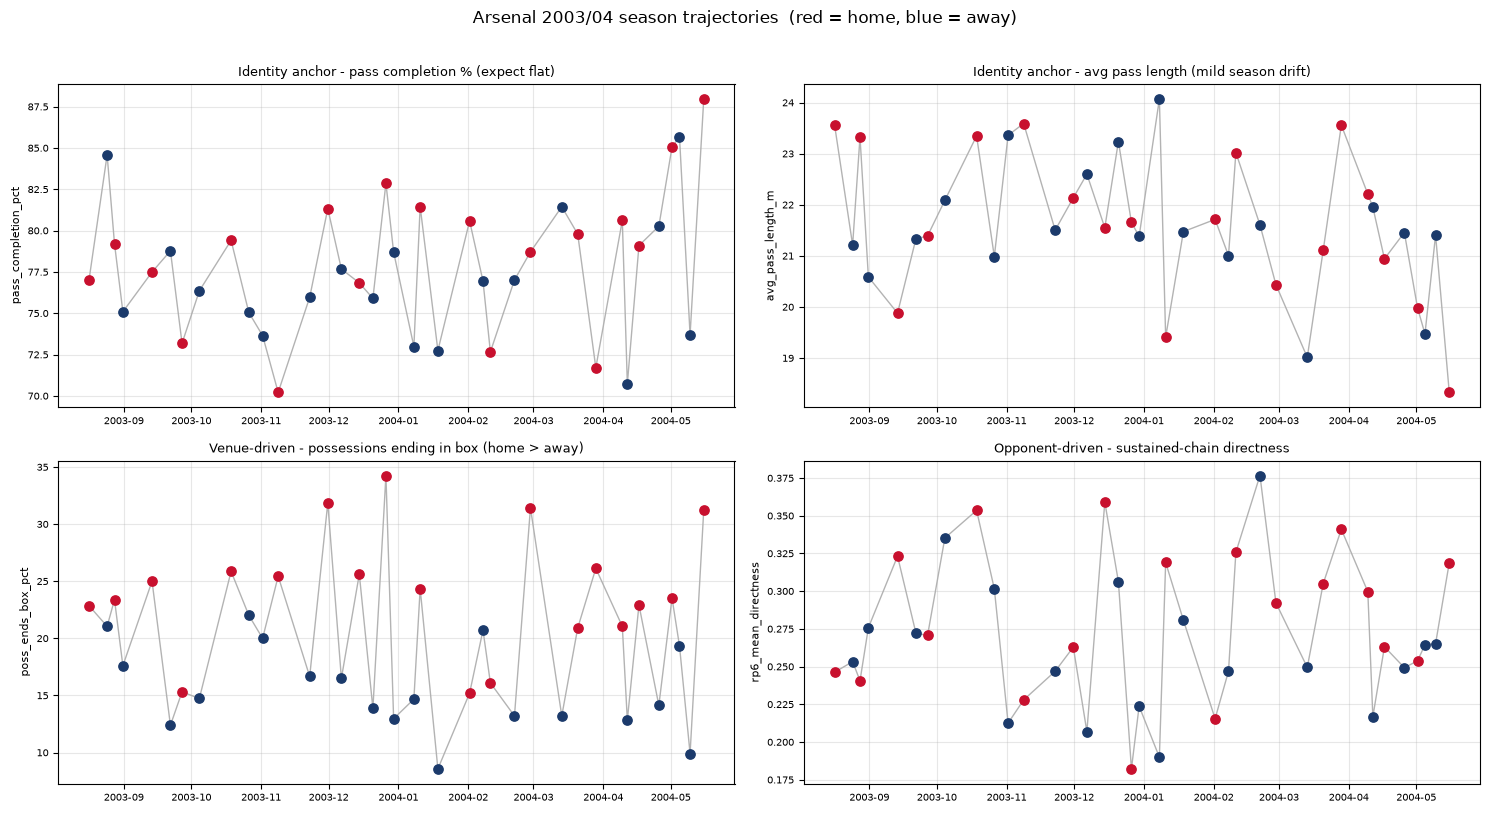

In [8]:
VENUE_COLOR = {"home": "#c8102e", "away": "#1b3a6b"}

def plot_metric_trajectory(df, metric, ax, title):
    d = df.sort_values("date")
    ax.plot(d["date"], d[metric], color="0.7", lw=1, zorder=1)
    for _, r in d.iterrows():
        ax.scatter(r["date"], r[metric], s=45,
                   color=VENUE_COLOR.get(r["venue"], "0.4"), zorder=2)
    ax.set_title(title, fontsize=9); ax.set_ylabel(metric, fontsize=8)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)

panels = [
    ("pass_completion_pct", "Identity anchor - pass completion % (expect flat)"),
    ("avg_pass_length_m",  "Identity anchor - avg pass length (mild season drift)"),
    ("poss_ends_box_pct",  "Venue-driven - possessions ending in box (home > away)"),
    ("rp6_mean_directness", "Opponent-driven - sustained-chain directness"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (m, t) in zip(axes.ravel(), panels):
    plot_metric_trajectory(ars, m, ax, t)
fig.suptitle("Arsenal 2003/04 season trajectories  (red = home, blue = away)", y=1.01)
fig.tight_layout(); plt.show()

### Distributions by venue — the sharpest view of the venue correction

> **Guiding question:** the regression *says* venue drives the territorial metrics;
> can we *see* it in the full distributions, not just the means? *(Answered by the
> violins below.)*

At n=38 each feature has 19 home and 19 away observations — enough to plot the whole
distribution, not just a coefficient. If venue is truly the driver, identity anchors
should show two **overlapping** violins (home ≈ away) while venue-driven features
show two **separated** ones. The standardized mean gap `|Δ|` (in σ units) quantifies
each panel.

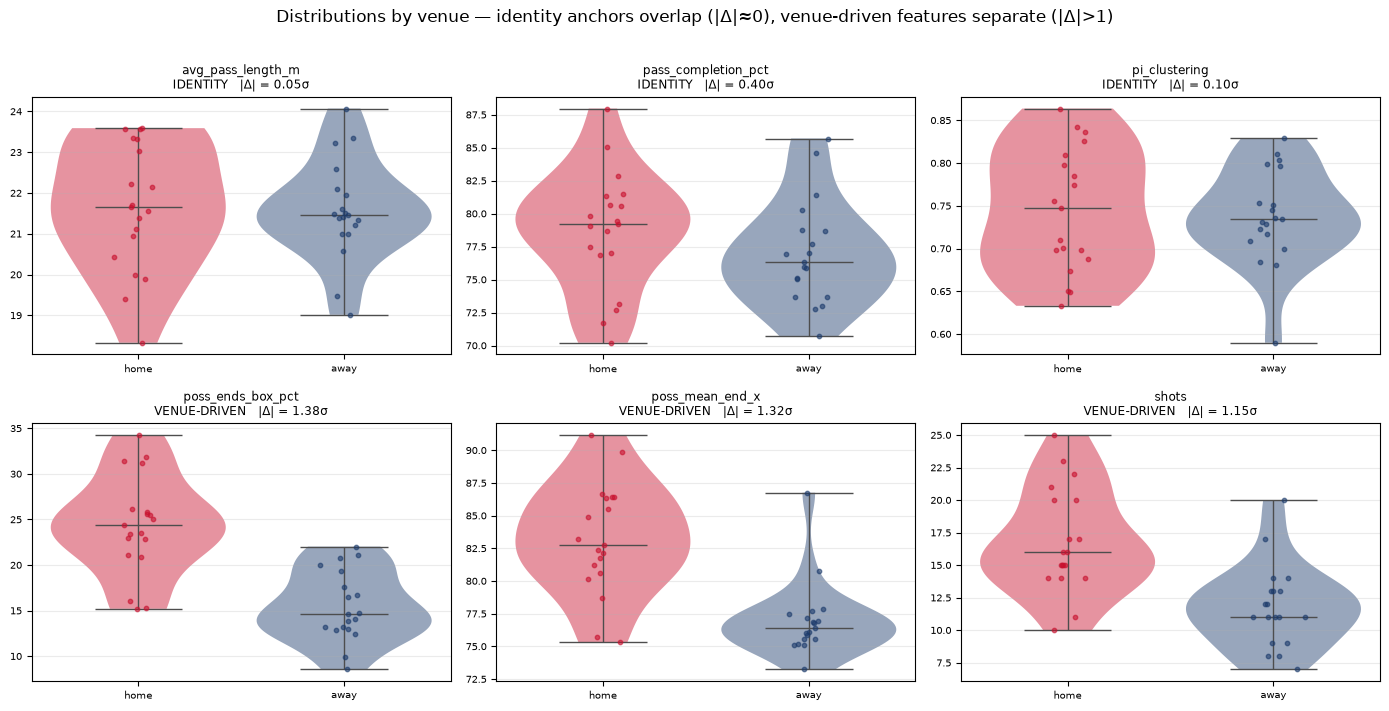

In [9]:
# Distributions split by venue (19 home vs 19 away). Top row: identity anchors ->
# home and away violins overlap. Bottom row: venue-driven context -> they separate.
# |Delta| = standardized mean gap between venues (in sigma units), printed per panel.
HOME_C, AWAY_C = "#c8102e", "#1b3a6b"
panels = [
    ("avg_pass_length_m", "identity"), ("pass_completion_pct", "identity"),
    ("pi_clustering",     "identity"),
    ("poss_ends_box_pct", "venue"),    ("poss_mean_end_x",     "venue"),
    ("shots",             "venue"),
]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (m, kind) in zip(axes.ravel(), panels):
    h = ars.loc[ars.venue == "home", m].dropna().values
    a = ars.loc[ars.venue == "away", m].dropna().values
    smd = abs(h.mean() - a.mean()) / ars[m].std()
    parts = ax.violinplot([h, a], positions=[1, 2], showmedians=True, widths=0.85)
    for pc, c in zip(parts["bodies"], [HOME_C, AWAY_C]):
        pc.set_facecolor(c); pc.set_alpha(0.45)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color("0.3"); parts[key].set_linewidth(1)
    for vals, pos, c in [(h, 1, HOME_C), (a, 2, AWAY_C)]:
        ax.scatter(rng.normal(pos, 0.05, len(vals)), vals, s=10, color=c, alpha=0.6, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["home", "away"], fontsize=8)
    tag = "IDENTITY" if kind == "identity" else "VENUE-DRIVEN"
    ax.set_title(f"{m}\n{tag}   |Δ| = {smd:.2f}σ", fontsize=8.5)
    ax.grid(alpha=0.25, axis="y"); ax.tick_params(labelsize=7)
fig.suptitle("Distributions by venue — identity anchors overlap (|Δ|≈0), "
             "venue-driven features separate (|Δ|>1)", y=1.01)
fig.tight_layout(); plt.show()

**The distributions make the correction visible.** The three identity anchors (top
row) have home and away violins sitting almost on top of each other — |Δ| ≈ 0.05–0.40σ
— Arsenal pass the same length, complete at the same rate, and keep the same network
shape wherever they play. The three territorial features (bottom row) separate
cleanly — |Δ| ≈ 1.1–1.4σ — home possessions end markedly higher up the pitch and in
the box far more often, with more shots. This is the venue effect the regression
isolated, shown now as whole distributions rather than a single coefficient: the
**identity is venue-invariant; the output is not.**

<hr>

## Redundancy before modeling

> **Guiding question:** now that n=38 makes correlation trustworthy, which features
> are genuinely redundant and can be collapsed before any modeling? *(Answered
> below.)*

Phase 1 flagged 394 `|r|>0.9` pairs at n=5 and correctly refused to prune (almost
all spurious). At n=38 the correlation matrix has the degrees of freedom to mean
something — we group features into collinear clusters and keep one representative
per cluster.

In [10]:
import itertools, collections

corr = ars[live].corr()
pairs = [(a, b, corr.loc[a, b])
         for a, b in itertools.combinations(live, 2) if abs(corr.loc[a, b]) > 0.9]
print(f"|r|>0.90 pairs at n=38: {len(pairs)}   "
      f"(Phase 1's n=5 pass had 394 - mostly spurious)")
print(f"|r|>0.95 pairs: {sum(abs(c) > 0.95 for *_, c in pairs)}")

# Connected components on the >0.9 graph = collinear clusters.
adj = collections.defaultdict(set)
for a, b, _ in pairs:
    adj[a].add(b); adj[b].add(a)
seen, clusters = set(), []
for f in live:
    if f in adj and f not in seen:
        stack, comp = [f], set()
        while stack:
            x = stack.pop()
            if x in comp:
                continue
            comp.add(x); seen.add(x)
            stack += [y for y in adj[x] if y not in comp]
        clusters.append(sorted(comp))
clusters.sort(key=len, reverse=True)
print(f"\n{len(seen)}/{len(live)} features fall into {len(clusters)} collinear "
      "clusters; keep one representative per cluster before modeling:")
for comp in clusters:
    print(f"  {comp}")

|r|>0.90 pairs at n=38: 23   (Phase 1's n=5 pass had 394 - mostly spurious)
|r|>0.95 pairs: 12

35/133 features fall into 15 collinear clusters; keep one representative per cluster before modeling:
  ['carries', 'events', 'passes']
  ['poss_ends_with_shot_pct', 'poss_poss_with_shot_pct', 'shots']
  ['poss_total_xg', 'xg', 'xg_per_possession']
  ['pi_first_long_pct', 'pi_first_pass_short_pct', 'pi_first_short_pct']
  ['poss_ends_final_third_pct', 'poss_final_third_entry_pct', 'poss_mean_end_x']
  ['avg_pass_length_m', 'long_pass_pct']
  ['crosses', 'crosses_per100pass']
  ['through_balls', 'through_balls_per100pass']
  ['pi_pressured_pass_pct', 'pressure_on_pass_pct']
  ['dribbles_complete', 'dribbles_complete_per100pass']
  ['pi_angle_entropy', 'pi_verticality']
  ['pi_first_forward_pct', 'pi_first_pass_forward_pct']
  ['pi_regular_play_buildups', 'rhythm_possessions']
  ['pi_progression_per_pass', 'pi_unpressured_mean_dx']
  ['pi_carry_progression_share_pct', 'pi_pass_progression_shar

**The real redundancy is small and interpretable — 23 pairs, not 394.** At n=38 only
23 feature pairs exceed `|r|>0.9` (12 exceed 0.95), collapsing **35 of 133 features
into 15 clusters**. Every cluster is a sensible near-duplicate: volume
(`passes`/`events`/`carries`), shot output
(`shots`/`poss_ends_with_shot_pct`/`poss_poss_with_shot_pct`), xG
(`xg`/`poss_total_xg`/`xg_per_possession`), first-pass length
(`pi_first_short_pct`/`_long_pct`), final-third territory
(`poss_mean_end_x`/`poss_ends_final_third_pct`/`poss_final_third_entry_pct`).
Keeping one representative per cluster removes ~20 redundant columns before
modeling without touching the tactical signal. The 94% shrinkage from the n=5
count is itself the lesson: small-sample collinearity was almost entirely noise.

## Feature classification & frozen registry

> **Guiding question:** pulling every diagnostic together, which features do we
> carry into cross-era modeling — as identity, as controls — and which do we drop as
> degenerate, redundant, or unresolved? *(Answered by the registry below, written to
> disk as the modeling hand-off.)*

This is the trustworthy, n=38 version of Phase 1's provisional tier registry. Each
feature is sorted by combining four signals already computed above:

- **drop** — degenerate (constant across all 38 games).
- **redundant** — a non-representative member of a collinear cluster (|r| > 0.9);
  we keep the lowest-CV member of each cluster and drop the rest.
- **context** — ≥ 30% of its variance is explained by date/venue/opponent *with a
  significant dominant driver* (p < 0.05): a genuine, structured adaptation.
- **identity** — low dispersion (CV ≤ median) and little context structure
  (R² < 0.30): the stable tactical DNA.
- **experimental** — everything else (real but weak/unresolved signal).

In [11]:
# Combine dispersion (CV), regression (context R^2 + significant driver), degeneracy,
# and redundancy (collinear-cluster membership) into one tier per feature.
cv_series = disp["cv"]
CV_MED = cv_series.median()
R2_HI = 0.30   # "context" only if >=30% of variance is context-explained AND significant

# one representative per collinear cluster (lowest CV); the rest are redundant
representative, cluster_of = {}, {}
for i, comp in enumerate(clusters):
    keep = min(comp, key=lambda c: cv_series.get(c, np.inf))
    for c in comp:
        representative[c] = keep
        cluster_of[c] = i

def tier_of(f):
    if f in degenerate:
        return "drop"
    if f in representative and representative[f] != f:
        return "redundant"
    r2, pval = reg.loc[f, "r2"], reg.loc[f, "dom_p"]
    if r2 >= R2_HI and pval < 0.05:
        return "context"
    if cv_series[f] <= CV_MED and r2 < R2_HI:
        return "identity"
    return "experimental"

tiers = {f: tier_of(f) for f in live}
tiers.update({d: "drop" for d in degenerate})

order = ["identity", "context", "experimental", "redundant", "drop"]
counts = pd.Series(tiers).value_counts().reindex(order).fillna(0).astype(int)
print(f"feature classification at n=38 (of {len(tiers)} features):")
print(counts.to_string())
print("\ncontext tier by dominant driver:")
print(pd.Series({f: reg.loc[f, "dominant"] for f in live if tiers[f] == "context"})
      .value_counts().to_string())
print("\nidentity anchors (lowest CV):",
      sorted([f for f in live if tiers[f] == "identity"], key=lambda f: cv_series[f])[:8])
print("context levers (highest R^2):",
      sorted([f for f in live if tiers[f] == "context"], key=lambda f: -reg.loc[f, "r2"]))

feature classification at n=38 (of 135 features):
identity        54
context          9
experimental    50
redundant       20
drop             2

context tier by dominant driver:
home    8
opp     1

identity anchors (lowest CV): ['pi_angle_entropy', 'rhythm_mean_burst_share', 'pi_unpressured_completion_pct', 'rhythm_median_gap_cv', 'pass_completion_pct', 'pi_centralization', 'pi_network_players', 'pi_avg_passes_to_wide_channel']
context levers (highest R^2): ['poss_ends_box_pct', 'poss_mean_end_x', 'rhythm_median_passes_per_10m', 'poss_box_entry_pct', 'pi_progressive_carry_pct', 'pi_progression_per_carry', 'shots', 'rp6_mean_directness', 'shots_per100pass']


## Feature map — the selection methodology in one figure

**This single scatter explains the entire feature-selection pipeline.** Every one of the 133 live features is placed by **stability** (x = coefficient of variation) and **context-dependence** (y = regression R²), and coloured by the **tier** it was assigned. Bottom-left (low CV, low R²) is the identity core; the labelled orange points are the context levers — their tags confirm the headline (venue-driven, with a single opponent lever, `rp6_mean_directness`); high-CV experimental features scatter to the right; the dashed lines are the CV-median and R²=0.30 thresholds that define the cuts.

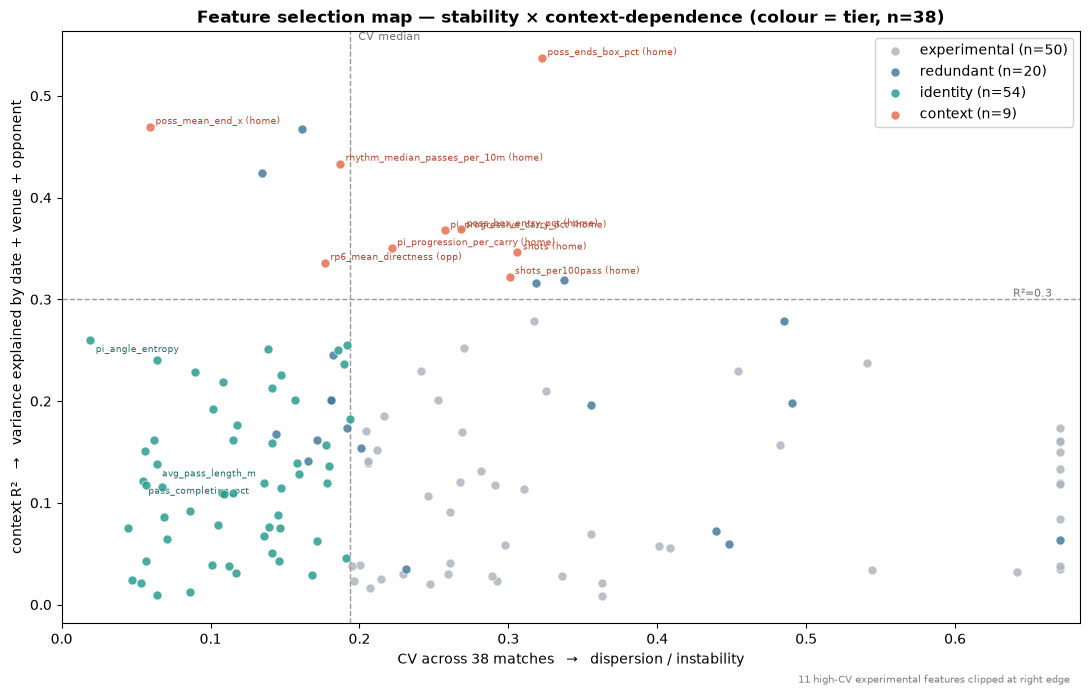

In [12]:
# The classification, as a picture: stability (x) against context-dependence (y),
# coloured by tier. The 9 context levers are labelled with their dominant driver,
# so the "venue, not opponent" correction is visible by name.
TIER_COLOR = {"identity": "#2a9d8f", "context": "#e76f51",
              "experimental": "#adb5bd", "redundant": "#457b9d"}
DRAW = ["experimental", "redundant", "identity", "context"]   # context on top

fig, ax = plt.subplots(figsize=(11, 7))
xcap = float(cv_series.quantile(0.92))
for z, t in enumerate(DRAW):
    fs = [f for f in live if tiers[f] == t]
    xs = np.clip([cv_series[f] for f in fs], None, xcap)
    ys = [reg.loc[f, "r2"] for f in fs]
    ax.scatter(xs, ys, s=42, alpha=0.85, color=TIER_COLOR[t],
               edgecolor="white", linewidth=0.5, zorder=z + 2,
               label=f"{t} (n={len(fs)})")

ax.axvline(CV_MED, ls="--", c="0.6", lw=1)
ax.axhline(R2_HI, ls="--", c="0.6", lw=1)
ax.text(CV_MED, ax.get_ylim()[1], "  CV median", va="top", fontsize=8, color="0.45")
ax.text(xcap, R2_HI, f"R²={R2_HI}  ", ha="right", va="bottom", fontsize=8, color="0.45")

for f in [f for f in live if tiers[f] == "context"]:            # label context levers
    ax.annotate(f"{f} ({reg.loc[f, 'dominant']})",
                (min(cv_series[f], xcap), reg.loc[f, "r2"]),
                fontsize=6.5, xytext=(4, 2), textcoords="offset points", color="#b3462f")
for f in ["pass_completion_pct", "pi_angle_entropy", "avg_pass_length_m"]:  # identity flagships
    if f in cv_series.index:
        ax.annotate(f, (min(cv_series[f], xcap), reg.loc[f, "r2"]),
                    fontsize=6.5, xytext=(4, -9), textcoords="offset points", color="#1f6f63")

ax.set_xlim(0, xcap * 1.02)
ax.set_xlabel("CV across 38 matches   →   dispersion / instability")
ax.set_ylabel("context R²   →   variance explained by date + venue + opponent")
ax.set_title("Feature selection map — stability × context-dependence (colour = tier, n=38)",
             fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
n_off = int((cv_series > xcap).sum())
if n_off:
    ax.text(0.99, -0.10, f"{n_off} high-CV experimental features clipped at right edge",
            transform=ax.transAxes, ha="right", fontsize=7, color="0.5")
plt.tight_layout(); plt.show()

In [13]:
# Freeze the validated, non-redundant registry to disk — the leakage-free hand-off
# to Phase 3 / modeling. Retained = identity (signal) + context (controls).
allf = live + degenerate
registry = pd.DataFrame({"feature": allf})
registry["tier"] = registry.feature.map(tiers)
registry["cv"] = registry.feature.map(lambda f: round(cv_series.get(f, np.nan), 4))
registry["context_r2"] = registry.feature.map(
    lambda f: round(reg.loc[f, "r2"], 4) if f in reg.index else np.nan)
registry["dominant"] = registry.feature.map(
    lambda f: reg.loc[f, "dominant"] if f in reg.index else "")
registry["dom_beta"] = registry.feature.map(
    lambda f: round(reg.loc[f, f"b_{reg.loc[f, 'dominant']}"], 3) if f in reg.index else np.nan)
registry["dom_p"] = registry.feature.map(
    lambda f: round(reg.loc[f, "dom_p"], 4) if f in reg.index else np.nan)
registry["cluster"] = registry.feature.map(lambda f: cluster_of.get(f, -1))
registry["representative"] = registry.feature.map(
    lambda f: (f not in representative) or (representative[f] == f))
registry["retained"] = registry.tier.isin(["identity", "context"])
registry = registry.sort_values(["tier", "cv"]).reset_index(drop=True)

out_path = FEATURES_DIR / "phase2_arsenal_feature_registry.csv"
registry.to_csv(out_path, index=False)
n_ret = int(registry.retained.sum())
print(f"wrote {out_path.name}: {len(registry)} features "
      f"({registry.tier.value_counts().reindex(order).fillna(0).astype(int).to_dict()})")
print(f"retained for modeling (identity + context): {n_ret}   |   "
      f"set aside: {len(registry) - n_ret}")
registry.head(12)

wrote phase2_arsenal_feature_registry.csv: 135 features ({'identity': 54, 'context': 9, 'experimental': 50, 'redundant': 20, 'drop': 2})
retained for modeling (identity + context): 63   |   set aside: 72


,feature,tier,cv,context_r2,dominant,dom_beta,dom_p,cluster,representative,retained
0,poss_mean_end_x,context,0.0594,0.4696,home,0.669,0.0000,4,True,True
1,rp6_mean_directness,context,0.1768,0.3360,opp,0.529,0.0006,-1,True,True
2,rhythm_median_passes_per_10m,context,0.1870,0.4335,home,-0.616,0.0000,-1,True,True
3,pi_progression_per_carry,context,0.2217,0.3504,home,0.547,0.0004,-1,True,True
4,pi_progressive_carry_pct,context,0.2573,0.3677,home,0.564,0.0002,-1,True,True
5,poss_box_entry_pct,context,0.2682,0.3691,home,0.566,0.0002,-1,True,True
6,shots_per100pass,context,0.3008,0.3224,home,0.554,0.0004,-1,True,True
7,shots,context,0.3060,0.3462,home,0.583,0.0002,1,True,True
8,poss_ends_box_pct,context,0.3226,0.5372,home,0.701,0.0000,-1,True,True
9,pi_pressure_escape_positive_carry_pct,drop,NaN,NaN,,NaN,NaN,-1,True,False


**The registry is the validated fingerprint, made portable.** Of 135 features the
scan retains **63 for modeling** — 54 low-CV **identity** anchors (the passing
machinery: completion, pass length, network density, rhythm) plus 9 **context**
levers with genuine, significant structure. Tellingly, those 9 split **8 venue-driven
to 1 opponent-driven**, the same correction the regression delivered, now baked into
the retained control set. The other 72 are set aside honestly: 20 **redundant**
(collapsed into their lowest-CV cluster representative), 2 **degenerate**, and 50
**experimental** (weak or unresolved at n=38 — revisited, not trusted). `phase2_arsenal_feature_registry.csv`
is the leakage-free artifact Phase 3 and the modeling stage load instead of
re-deriving tiers: identity features supply the cross-era fingerprint, context
features stay as covariates, and the dropped columns never enter the design matrix.

<hr>

## Synthesis — validated tactical fingerprint of Arsenal 2003/04

**The pipeline generalizes unchanged.** Every Phase 1 diagnostic — dispersion,
degeneracy, context decomposition, redundancy — ran on all 38 matches without a
single metric being modified, with zero NaNs, and reproduced the identity
discovered from one match. That is the validation this phase set out to prove.

**The fingerprint (stable identity).** Across the entire unbeaten season Arsenal's
DNA holds within tight bounds: short passing (`avg_pass_length_m` CV 0.06), high
completion (0.05), consistent passing geometry (`pi_angle_entropy` 0.02), a dense
central network (`pi_centralization` / `pi_network_players` 0.06), and steady
rhythm (`rhythm_mean_burst_share` 0.05). These are context-independent — low CV
*and* low regression R².

**The context adaptations (honestly attributed).** What varies splits cleanly once
venue and opponent are separated: **home/away** drives territory (box entries,
final-third occupation, shots — Arsenal push higher at home); **opponent strength**
drives a narrower, modest shift in sustained-possession directness and fouls (more
direct, more fouls vs stronger sides); and a **mild season drift** trends toward
shorter, more lateral passing. The Phase 1 'context lever' story was largely a
venue effect the 5-match sample could not separate — the single most important
correction this phase delivers.

**Ready for cross-era comparison.** With the fingerprint validated and the pipeline
proven season-general, the same code can be pointed at the fully-captured 2015/16
season. **Phase 3** applies it there and sets up the intended payoff — the
Invincibles vs Leicester, top team vs top team — a comparison that is only
trustworthy now that both the metric *and* its season-wide behaviour have been
validated.

**The hand-off, stated explicitly.** The validated **identity** features now form the design matrix for cross-era comparison; the **context** features are retained as covariates (venue, opponent, season drift); and the **redundant** and **degenerate** features are excluded from all subsequent analyses. The frozen registry (`phase2_arsenal_feature_registry.csv`, 63 retained) is exactly this contract, carried into Phase 3.